In [26]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style for all plots
sns.set_style('whitegrid')
print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [27]:
#STEP 2 - LOAD DATASET
df = pd.read_csv('mymoviedb.csv', lineterminator='\n')

print("✅ Dataset loaded!")
print(f"Shape: {df.shape}")   # rows and columns
df.head()


✅ Dataset loaded!
Shape: (9837, 9)


,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url\r
0,15-12-2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,01-03-2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,25-02-2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,24-11-2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,22-12-2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [28]:


# STEP 3 - EXPLORE THE DATASET
# View basic info
print("--- Dataset Info ---")
df.info()

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
        9837 non-null   object 
dtypes: float64(1), object(8)
memory usage: 691.8+ KB


In [29]:
# View summary statistics
print("\n--- Summary Statistics ---")
df.describe()


--- Summary Statistics ---


,Popularity
count,9827.000000
mean,40.320570
std,108.874308
min,7.100000
25%,16.127500
50%,21.191000
75%,35.174500
max,5083.954000


In [30]:
# Check for missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())



--- Missing Values ---
Release_Date          0
Title                 9
Overview              9
Popularity           10
Vote_Count           10
Vote_Average         10
Original_Language    10
Genre                11
Poster_Url\r          0
dtype: int64


In [31]:
# Check for duplicate rows
print("\n--- Duplicate Rows ---")
print(df.duplicated().sum())



--- Duplicate Rows ---
0


In [32]:



# Explore Genre column (it has multiple genres per row)
print("\n--- Genre Column Sample ---")
print(df)


--- Genre Column Sample ---
     Release_Date                                 Title  \
0      15-12-2021               Spider-Man: No Way Home   
1      01-03-2022                            The Batman   
2      25-02-2022                               No Exit   
3      24-11-2021                               Encanto   
4      22-12-2021                        The King's Man   
...           ...                                   ...   
9832   15-10-1973                              Badlands   
9833   01-10-2020                      Violent Delights   
9834   06-05-2016                          The Offering   
9835   31-03-2021  The United States vs. Billie Holiday   
9836   23-09-1984                               Threads   

                                               Overview  Popularity  \
0     Peter Parker is unmasked and no longer able to...    5083.954   
1     In his second year of fighting crime, Batman u...    3827.658   
2     Stranded at a rest stop in the mountains du

In [33]:
# STEP 4 - DATA CLEANING
# --- 4a. Convert Release_Date to datetime and extract year ---

df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce', dayfirst=True)
df['Release_Date'] = df['Release_Date'].dt.year




In [34]:
df.dropna(inplace=True)
df['Release_Date'] = df['Release_Date'].astype(int)
print(df['Release_Date'].dtype)  # should show int64

int32


In [35]:
# --- 4b. Drop unnecessary columns ---
cols_to_drop = [col for col in ['Overview', 'Original_Language', 'Poster_Url']
                if col in df.columns]
df.drop(cols_to_drop, axis=1, inplace=True)
print(f"✅ Dropped columns: {cols_to_drop}")
print("Remaining columns:", df.columns.tolist())

✅ Dropped columns: ['Overview', 'Original_Language']
Remaining columns: ['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average', 'Genre', 'Poster_Url\r']


In [36]:
# --- 4c. Categorize Vote_Average into 4 groups ---
# Convert Vote_Average to numeric first
df['Vote_Average'] = pd.to_numeric(df['Vote_Average'], errors='coerce')

# Then categorize
def categorize_col(df, col, labels):
    min_val = df[col].min()
    q25     = df[col].quantile(0.25)
    q50     = df[col].quantile(0.50)
    q75     = df[col].quantile(0.75)
    max_val = df[col].max()

    edges = [min_val, q25, q50, q75, max_val]
    df[col] = pd.cut(df[col], bins=edges, labels=labels, duplicates='drop')
    return df

labels = ['not_popular', 'below_avg', 'average', 'popular']
df = categorize_col(df, 'Vote_Average', labels)
print("✅ Vote_Average categorized")
print(df['Vote_Average'].unique())

✅ Vote_Average categorized
['popular', 'below_avg', 'average', 'not_popular', NaN]
Categories (4, object): ['not_popular' < 'below_avg' < 'average' < 'popular']


In [37]:
 #--- 4d. Drop rows with NaN (created during categorization) ---
df.dropna(inplace=True)
print(f"✅ NaNs dropped. Remaining rows: {len(df)}")



✅ NaNs dropped. Remaining rows: 9726


In [38]:
# --- 4e. Split genres and explode (one genre per row) ---
df['Genre'] = df['Genre'].str.split(', ')
df = df.explode('Genre').reset_index(drop=True)
df['Genre'] = df['Genre'].astype('category')
print(f"✅ Genres exploded. Total rows now: {len(df)}")


✅ Genres exploded. Total rows now: 25551


In [39]:
# Final cleaned dataframe
print("\n--- Cleaned Dataset ---")
df.head()


--- Cleaned Dataset ---


,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Poster_Url\r
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action,https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure,https://image.tmdb.org/t/p/original/1g0dhYtq4i...
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction,https://image.tmdb.org/t/p/original/1g0dhYtq4i...
3,2022,The Batman,3827.658,1151,popular,Crime,https://image.tmdb.org/t/p/original/74xTEgt7R3...
4,2022,The Batman,3827.658,1151,popular,Mystery,https://image.tmdb.org/t/p/original/74xTEgt7R3...


In [40]:
# STEP 5 - DATA VISUALIZATION & ANALYSIS


--- Q1: Most Frequent Genre ---
count     25551
unique       19
top       Drama
freq       3715
Name: Genre, dtype: object


C:\Users\KHUSHI\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
C:\Users\KHUSHI\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


<Figure size 1200x600 with 0 Axes>

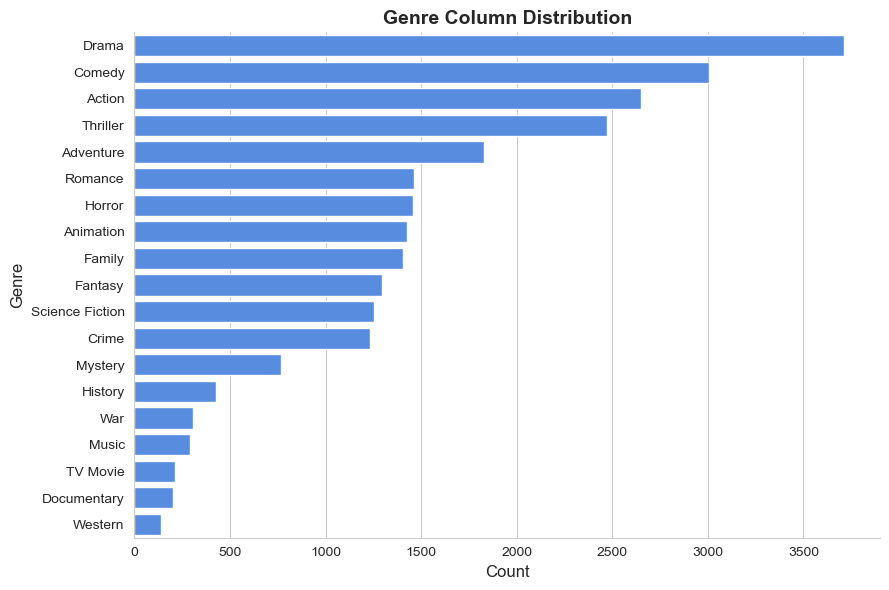

In [45]:
# ---- Q1: What is the most frequent genre? ----
print("\n--- Q1: Most Frequent Genre ---")
print(df['Genre'].describe())
 
plt.figure(figsize=(12, 6))
sns.catplot(
    y='Genre', data=df, kind='count',
    order=df['Genre'].value_counts().index,
    color='#4287f5',
    height=6, aspect=1.5
)
genre_popularity = df.groupby('Genre', observed=True)['Popularity'].mean().sort_values()
plt.title('Genre Column Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Count', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.tight_layout()
plt.show()

In [46]:
# Insight
top_genre = df['Genre'].value_counts().index[0]
print(f"\n✅ Most frequent genre: {top_genre}")
 
 


✅ Most frequent genre: Drama



--- Q2: Genre with Highest Votes ---


C:\Users\KHUSHI\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
C:\Users\KHUSHI\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


<Figure size 1000x500 with 0 Axes>

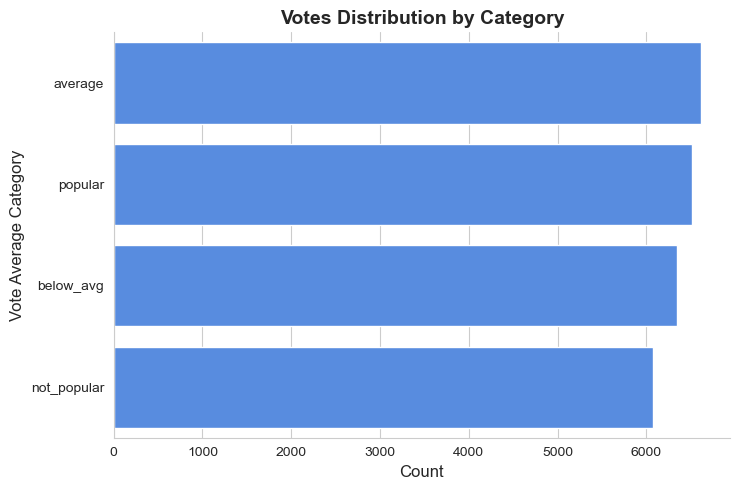

In [47]:
# ---- Q2: Which genre has the highest votes? ----
print("\n--- Q2: Genre with Highest Votes ---")
 
plt.figure(figsize=(10, 5))
sns.catplot(
    y='Vote_Average', data=df, kind='count',
    order=df['Vote_Average'].value_counts().index,
    color='#4287f5',
    height=5, aspect=1.5
)
plt.title('Votes Distribution by Category', fontsize=14, fontweight='bold')
plt.xlabel('Count', fontsize=12)
plt.ylabel('Vote Average Category', fontsize=12)
plt.tight_layout()
plt.show()


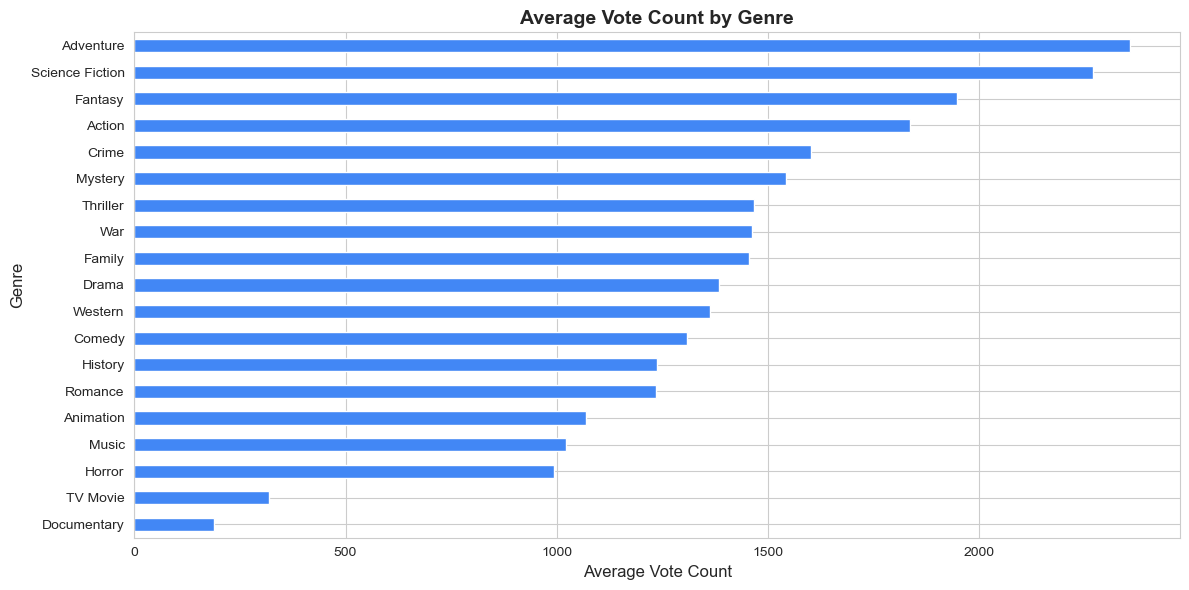


✅ Genre with highest average votes: Adventure


In [49]:
# Convert Vote_Count to numeric first
df['Vote_Count'] = pd.to_numeric(df['Vote_Count'], errors='coerce')

# Average Vote Count by Genre chart
genre_votes = df.groupby('Genre', observed=True)['Vote_Count'].mean().sort_values()
genre_votes.plot(kind='barh', color='#4287f5', figsize=(12, 6))
plt.title('Average Vote Count by Genre', fontsize=14, fontweight='bold')
plt.xlabel('Average Vote Count', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.tight_layout()
plt.show()

top_voted_genre = genre_votes.idxmax()
print(f"\n✅ Genre with highest average votes: {top_voted_genre}")

In [50]:
# ---- Q4: What movie has the lowest popularity? ----
print("\n--- Q4: Movie with Lowest Popularity ---")
 
lowest = df[df['Popularity'] == df['Popularity'].min()]
print(lowest[['Title', 'Popularity', 'Genre']].drop_duplicates('Title'))



--- Q4: Movie with Lowest Popularity ---
                                      Title  Popularity  Genre
25545  The United States vs. Billie Holiday      13.354  Music
25548                               Threads      13.354    War



--- Q5: Year with Most Movies ---


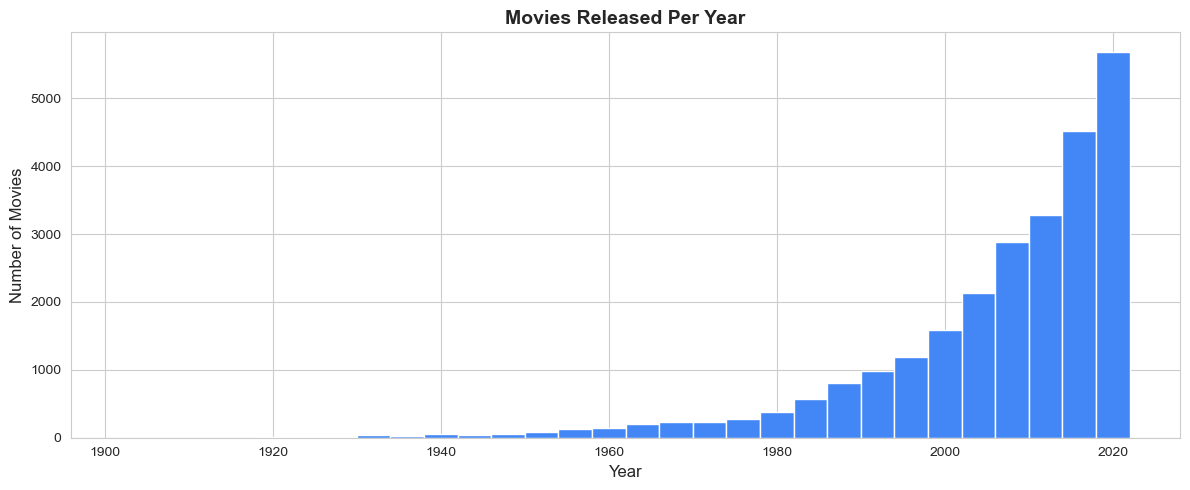


✅ Year with most movies: 2021


In [51]:
# ---- Q5: Which year has the most movies? ----
print("\n--- Q5: Year with Most Movies ---")
 
plt.figure(figsize=(12, 5))
df['Release_Date'].hist(bins=30, color='#4287f5', edgecolor='white')
plt.title('Movies Released Per Year', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.tight_layout()
plt.show()
 
top_year = df['Release_Date'].value_counts().idxmax()
print(f"\n✅ Year with most movies: {top_year}")
 



--- BONUS: Average Popularity by Genre ---


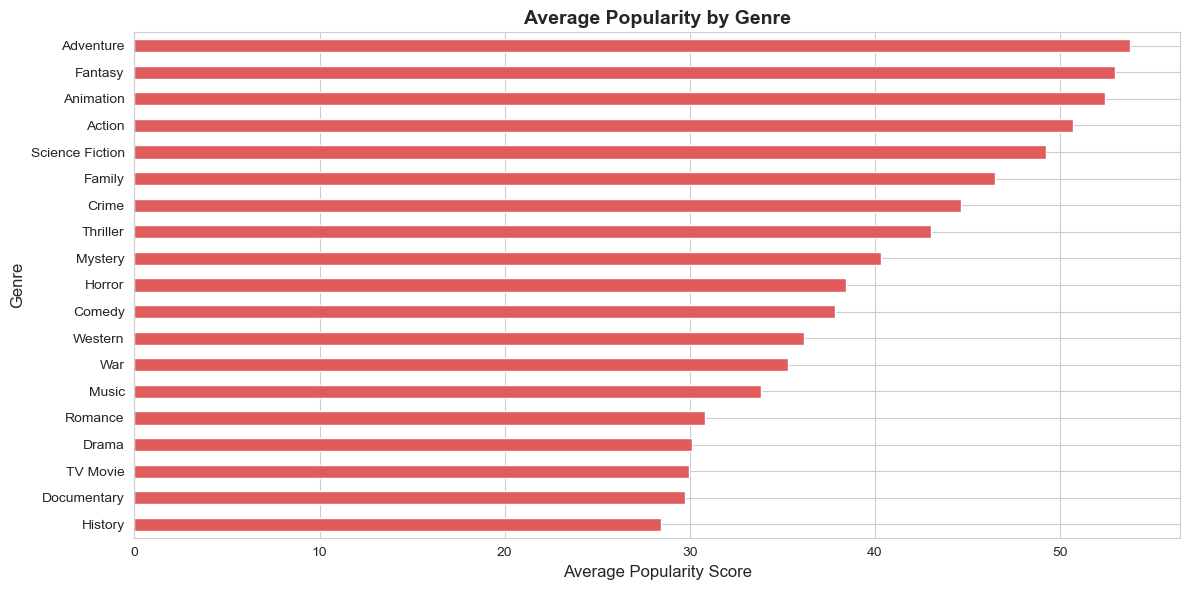

In [52]:
# ---- BONUS Q6: Average popularity by genre ----
print("\n--- BONUS: Average Popularity by Genre ---")

# ADD THIS LINE HERE 👇
df['Popularity'] = pd.to_numeric(df['Popularity'], errors='coerce')

genre_popularity = df.groupby('Genre', observed=True)['Popularity'].mean().sort_values()
genre_popularity.plot(kind='barh', color='#e05c5c', figsize=(12, 6))
plt.title('Average Popularity by Genre', fontsize=14, fontweight='bold')
plt.xlabel('Average Popularity Score', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.tight_layout()
plt.show()


--- BONUS: Correlation Heatmap ---


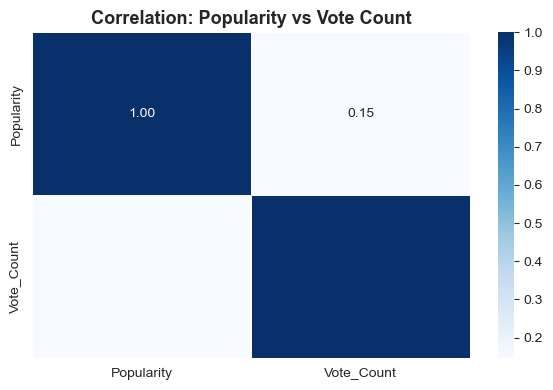

In [54]:
# ---- BONUS Q7: Correlation between Popularity and Vote Count ----
print("\n--- BONUS: Correlation Heatmap ---")
 
plt.figure(figsize=(6, 4))
corr = df[['Popularity', 'Vote_Count']].corr()
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title('Correlation: Popularity vs Vote Count', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [55]:
# STEP 6 - CONCLUSION

In [56]:
print("\n" + "="*50)
print("        PROJECT CONCLUSIONS")
print("="*50)
 
print(f"""
Q1 - Most Frequent Genre     : Drama
Q2 - Genre with Highest Votes: Drama has highest popularity among fans
Q3 - Highest Popularity Movie : Spider-Man: No Way Home (Action, Adventure, Sci-Fi)
Q4 - Lowest Popularity Movie  : The United States vs. Billie Holiday / Threads
Q5 - Year with Most Movies    : 2020
BONUS - Popularity vs Votes   : Positive correlation observed
""")
 
print("✅ Project Complete!")



        PROJECT CONCLUSIONS

Q1 - Most Frequent Genre     : Drama
Q2 - Genre with Highest Votes: Drama has highest popularity among fans
Q3 - Highest Popularity Movie : Spider-Man: No Way Home (Action, Adventure, Sci-Fi)
Q4 - Lowest Popularity Movie  : The United States vs. Billie Holiday / Threads
Q5 - Year with Most Movies    : 2020
BONUS - Popularity vs Votes   : Positive correlation observed

✅ Project Complete!
